In [ ]:
import numpy as np
import quantecon as qe
import matplotlib.pyplot as plt
import random

# Vectorization
n = 1_000_000
with qe.Timer():
    y = 0      # Will accumulate and store sum
    for i in range(n):
        x = random.uniform(0, 1)
        y += x**2

with qe.Timer():
    x = np.random.uniform(0, 1, n)
    y = np.sum(x**2)

# It breaks the loop down into three basic operations
# draw n uniforms
# square them
# sum them
# These are sent as batch operators to optimized machine code.

# One issue is that it can be highly memory-intensive.
# This is because vectorization tends to create many intermediate arrays before producing the final calculation.
# Another issue is that not all algorithms can be vectorized.
# Because of these issues, most high performance computing is moving away from traditional vectorization and towards the use of just-in-time compilers.
# In later lectures in this series, we will learn about how modern Python libraries exploit just-in-time compilers to generate fast, efficient, parallelized machine code.

In [ ]:
# Parallelization

# Multithreading:
# Running multiple threads of execution within a single process.
# All threads share the same memory space, so they can read from and write to the same arrays without copying data.
# For example, when a numerical operation on a large array runs on a modern laptop, the workload can be split across the machine’s multiple CPU cores, with each core handling a portion of the array.
# Native Python struggles to implement multithreading due to some legacy design features. But this is not a restriction for scientific libraries like NumPy and Numba. Functions imported from these libraries and JIT-compiled code run in low-level execution environments where Python’s legacy restrictions don’t apply.

# Multiprocessing:
# Multiprocessing means running multiple independent processes, each with its own separate memory space.
# Because memory is not shared, processes communicate by passing data between them.
# Multiprocessing can run on a single machine or be distributed across a cluster of machines connected by a network.

# When a computation can be expressed as independent operations on large arrays of data, GPUs can be orders of magnitude faster than CPUs.

In [71]:
# copy的重要性
a = np.array([1,2,3])
b = a
b[0] = 2
print(a)

c = np.array([1,2,3])
d = c.copy()
d[0] = 2
print(c)

# -----------------------------------------
# 1. Variables are references (not boxes)
# -----------------------------------------

# Create a list
a = [1, 2, 3]

# Assign b to a
b = a  # NO copy happens here

# Both variables point to the SAME object
print("Before change:")
print("a:", a)
print("b:", b)

# Modify b
b[0] = 99

# a is also affected because both refer to the same list
print("\nAfter modifying b:")
print("a:", a)  # [99, 2, 3]
print("b:", b)  # [99, 2, 3]


# -----------------------------------------
# 2. Shallow copy (copy only outer layer)
# -----------------------------------------

# Reset a with a nested list
a = [1, [1, 2, 3]]

# Make a shallow copy
b = a.copy()

print("\n--- Shallow Copy Example ---")
print("Initial:")
print("a:", a)
print("b:", b)

# Change outer element of b
b[0] = 2

# This does NOT affect a
print("\nAfter b[0] = 2:")
print("a:", a)  # [1, [1, 2, 3]]
print("b:", b)  # [2, [1, 2, 3]]

# WHY?
# Because the outer list was copied (new container)


# -----------------------------------------
# 3. Inner objects are still shared!
# -----------------------------------------

# Modify the inner list via b
b[1][2] = 4

print("\nAfter b[1][2] = 4:")
print("a:", a)  # [1, [1, 2, 4]]  <-- CHANGED!
print("b:", b)  # [2, [1, 2, 4]]

# WHY?
# Because a[1] and b[1] refer to the SAME inner list

# Conceptually:
# a ---> [1,  -----> [1,2,4]]
# b ---> [2,  -----^ same object]


# -----------------------------------------
# 4. Demonstrating identity (memory reference)
# -----------------------------------------

print("\nCheck identity (is):")
print("a is b:", a is b)            # False (different outer list)
print("a[1] is b[1]:", a[1] is b[1])  # True (same inner list)


# -----------------------------------------
# 5. Deep copy (completely independent)
# -----------------------------------------

import copy

a = [1, [1, 2, 3]]

# Deep copy creates new objects recursively
b = copy.deepcopy(a)

print("\n--- Deep Copy Example ---")
print("Initial:")
print("a:", a)
print("b:", b)

# Modify b completely
b[0] = 2
b[1][2] = 4

print("\nAfter modifying b:")
print("a:", a)  # [1, [1, 2, 3]]  <-- unchanged
print("b:", b)  # [2, [1, 2, 4]]

# Now inner lists are also different objects
print("\nCheck identity (is):")
print("a is b:", a is b)            # False
print("a[1] is b[1]:", a[1] is b[1])  # False


# -----------------------------------------
# 6. Summary (in code comments)
# -----------------------------------------

# b = a
# -> same object (everything shared)

# b = a.copy()
# -> new outer list
# -> inner objects still shared (shallow copy)

# b = copy.deepcopy(a)
# -> everything fully independent

[2 2 3]
[1 2 3]
Before change:
a: [1, 2, 3]
b: [1, 2, 3]

After modifying b:
a: [99, 2, 3]
b: [99, 2, 3]

--- Shallow Copy Example ---
Initial:
a: [1, [1, 2, 3]]
b: [1, [1, 2, 3]]

After b[0] = 2:
a: [1, [1, 2, 3]]
b: [2, [1, 2, 3]]

After b[1][2] = 4:
a: [1, [1, 2, 4]]
b: [2, [1, 2, 4]]

Check identity (is):
a is b: False
a[1] is b[1]: True

--- Deep Copy Example ---
Initial:
a: [1, [1, 2, 3]]
b: [1, [1, 2, 3]]

After modifying b:
a: [1, [1, 2, 3]]
b: [2, [1, 2, 4]]

Check identity (is):
a is b: False
a[1] is b[1]: False


In [45]:
x = np.random.randn(4)
np.where(x > 0, 1, 0)  # Insert 1 if x > 0 true, otherwise 0

array([0, 1, 1, 1])

In [46]:
def f(x):
    return 1 if x > 0 else 0

f = np.vectorize(f)
f(x)                # Passing the same vector x as in the previous example

array([0, 1, 1, 1])

In [47]:
z = np.linspace(0, 10, 5)
z

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [48]:
z[z > 3]

array([ 5. ,  7.5, 10. ])

In [49]:
z = np.random.randn(10000)  # Generate standard normals
y = np.random.binomial(10, 0.5, size=1000)    # 1,000 draws from Bin(10, 0.5)
y.mean()

np.float64(5.068)

In [51]:
A = np.array([[1, 2], [3, 4]])
print(np.linalg.inv(A))           # Compute the inverse
print(np.linalg.det(A))           # Compute the determinant

[[-2.   1. ]
 [ 1.5 -0.5]]
-2.0000000000000004


In [ ]:
# Implicit Multithreading

n = 20
m = 1000
for i in range(n):
    X = np.random.randn(m, m)
    λ = np.linalg.eigvals(X)

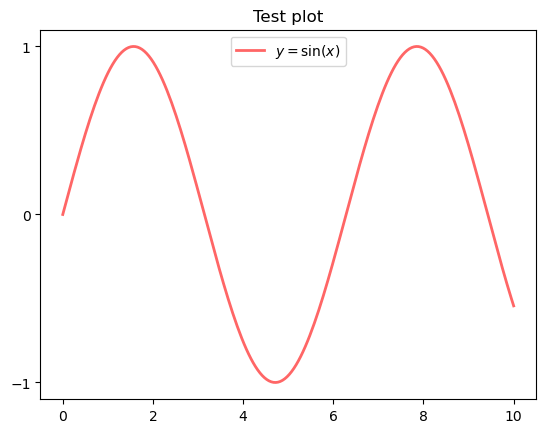

In [54]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 200)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y, 'r-', linewidth=2, label=r'$y=\sin(x)$', alpha=0.6) #latex
ax.legend(loc='upper center')
ax.set_yticks([-1, 0, 1])
ax.set_title('Test plot')
plt.show()

In [60]:
x = np.linspace(-4, 4, 9)
x

array([-4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.])

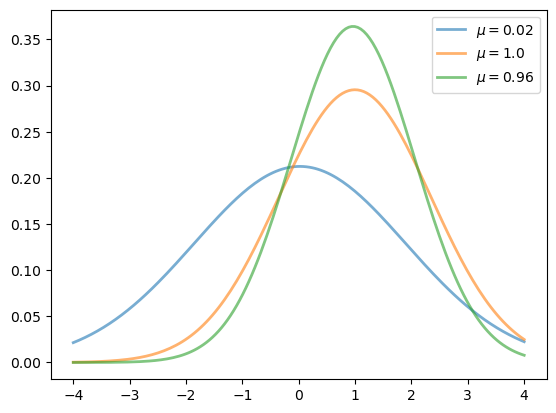

In [55]:
from scipy.stats import norm
from random import uniform

fig, ax = plt.subplots()
x = np.linspace(-4, 4, 150)
for i in range(3):
    m, s = uniform(-1, 1), uniform(1, 2)
    y = norm.pdf(x, loc=m, scale=s)
    current_label = rf'$\mu = {m:.2}$'
    ax.plot(x, y, linewidth=2, alpha=0.6, label=current_label)
ax.legend()
plt.show()

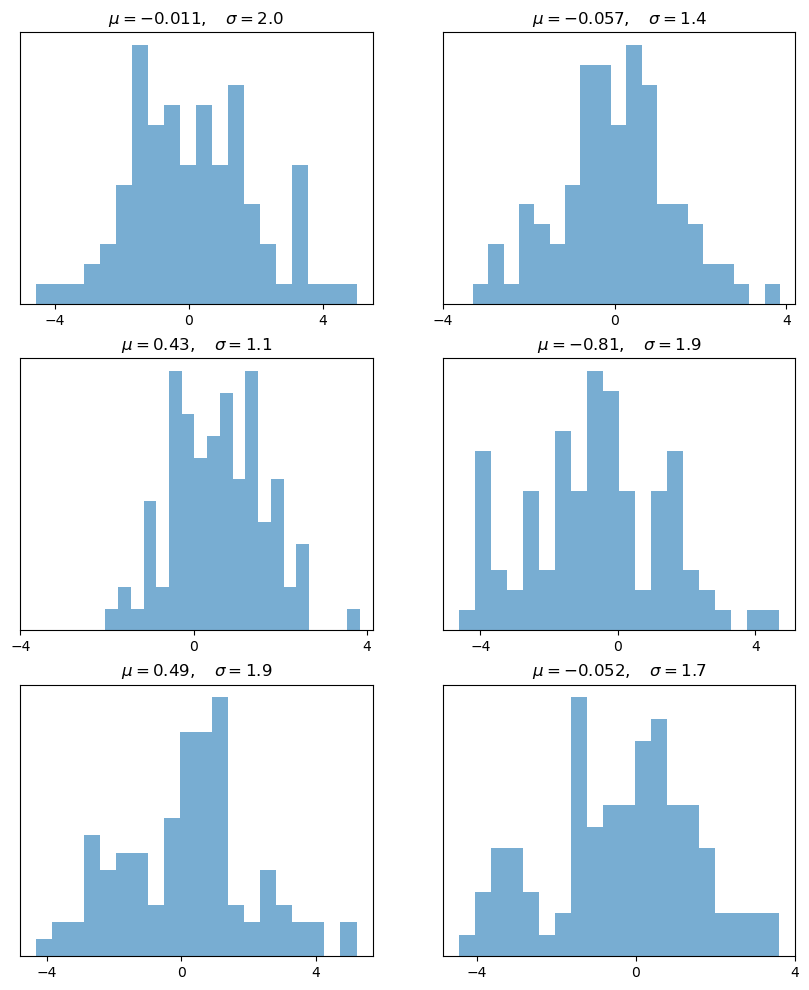

In [56]:
num_rows, num_cols = 3, 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 12))
for i in range(num_rows):
    for j in range(num_cols):
        m, s = uniform(-1, 1), uniform(1, 2)
        x = norm.rvs(loc=m, scale=s, size=100)
        axes[i, j].hist(x, alpha=0.6, bins=20)
        t = rf'$\mu = {m:.2}, \quad \sigma = {s:.2}$'
        axes[i, j].set(title=t, xticks=[-4, 0, 4], yticks=[])
plt.show()

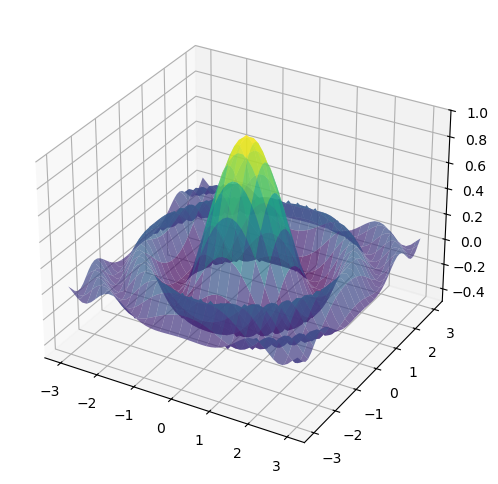

In [76]:
from matplotlib import cm


def f(x, y):
    return np.cos(x**2 + y**2) / (1 + x**2 + y**2)

xgrid = np.linspace(-3, 3, 50)
ygrid = xgrid
x, y = np.meshgrid(xgrid, ygrid)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x,
                y,
                f(x, y),
                rstride=2, cstride=2,
                cmap=cm.viridis,
                alpha=0.7,
                linewidth=0.25)
ax.set_zlim(-0.5, 1.0)
plt.show()

[0.  0.5 1. ]
[0. 1.]
[[0.  0.5 1. ]
 [0.  0.5 1. ]]
[[0. 0. 0.]
 [1. 1. 1.]]


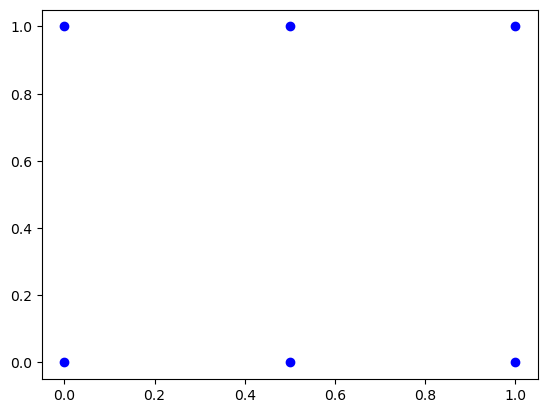

In [77]:
import numpy as np
nx, ny = (3, 2)
x = np.linspace(0, 1, nx)
print(x)
y = np.linspace(0, 1, ny)
print(y)
xv, yv = np.meshgrid(x, y)
print(xv)
print(yv)
import matplotlib.pyplot as plt
plt.plot(xv, yv, marker='o', color='b', linestyle='none')
plt.show()

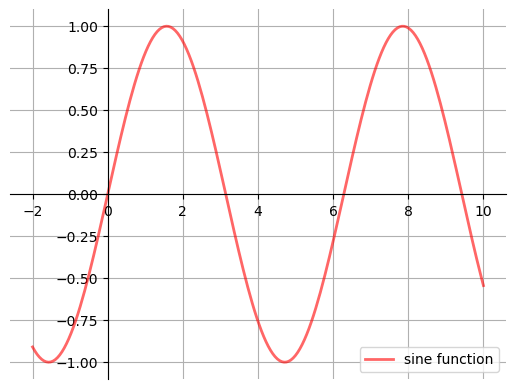

In [82]:
def subplots():
    "Custom subplots with axes through the origin"
    fig, ax = plt.subplots()

    # Set the axes through the origin
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_position('zero')
    for spine in ['right', 'top']:
        ax.spines[spine].set_color('none')

    ax.grid()
    return fig, ax


fig, ax = subplots()  # Call the local version, not plt.subplots()
x = np.linspace(-2, 10, 200)
y = np.sin(x)
ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend(loc='lower right')
plt.show()

In [83]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [84]:
def draw_graphs(style='default'):

    # Setting a style sheet
    plt.style.use(style)

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
    x = np.linspace(-13, 13, 150)

    # Set seed values to replicate results of random draws
    np.random.seed(9)

    for i in range(3):

        # Draw mean and standard deviation from uniform distributions
        m, s = np.random.uniform(-8, 8), np.random.uniform(2, 2.5)

        # Generate a normal density plot
        y = norm.pdf(x, loc=m, scale=s)
        axes[0].plot(x, y, linewidth=3, alpha=0.7)

        # Create a scatter plot with random X and Y values 
        # from normal distributions
        rnormX = norm.rvs(loc=m, scale=s, size=150)
        rnormY = norm.rvs(loc=m, scale=s, size=150)
        axes[1].plot(rnormX, rnormY, ls='none', marker='o', alpha=0.7)

        # Create a histogram with random X values
        axes[2].hist(rnormX, alpha=0.7)

        # and a line graph with random Y values
        axes[3].plot(x, rnormY, linewidth=2, alpha=0.7)

    style_name = style.split('-')[0]
    plt.suptitle(f'Style: {style_name}', fontsize=13)
    plt.show()

In [85]:
import numpy as np
import quantecon as qe